In [1]:
%load_ext autoreload
%autoreload 3


import logging

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(name)s - %(message)s'
)

import pandas as pd
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

from explainit.priorities.nonlinear import exponential
from explainit.explainers.minlp_search import MINLSearchExplainer

import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names")

In [2]:
# Example: Load German Credit dataset
df = pd.read_csv('data/german_credit_data.csv')  # Replace with your dataset path

# Improved preprocessing for your dataset

# Drop 'Unnamed: 0' as it's just an index
df = df.drop(columns=['Unnamed: 0'])

# Handle missing values in categorical columns by filling with 'missing'
cat_cols = ['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']
num_cols = ['Age', 'Credit amount','Duration']

df[cat_cols] = df[cat_cols].fillna('missing')

# Encode target: convert 'Risk' to binary (e.g., 'good' = 1, 'bad' = 0)
df['target'] = (df['Risk'] == 'good').astype(int)
df = df.drop(columns=['Risk'])

# Separate features and target
X = df.drop('target', axis=1)
y = df['target']

# Scale numerical features
scaler = MinMaxScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

# One-hot encode categorical features
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_cat = pd.DataFrame(encoder.fit_transform(X[cat_cols]), columns=encoder.get_feature_names_out(cat_cols), index=X.index)
X = pd.concat([X[num_cols], X_cat], axis=1)

# Separate features and target
X = df.drop('target', axis=1)
y = df['target']


scaler = MinMaxScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_cat = pd.DataFrame(encoder.fit_transform(X[cat_cols]), columns=encoder.get_feature_names_out(cat_cols))
X = pd.concat([X[num_cols], X_cat], axis=1)
for col in encoder.get_feature_names_out(encoder.feature_names_in_):
    X[col] = X[col].astype('category')
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a classifier (Logistic Regression)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict and check accuracy
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.76




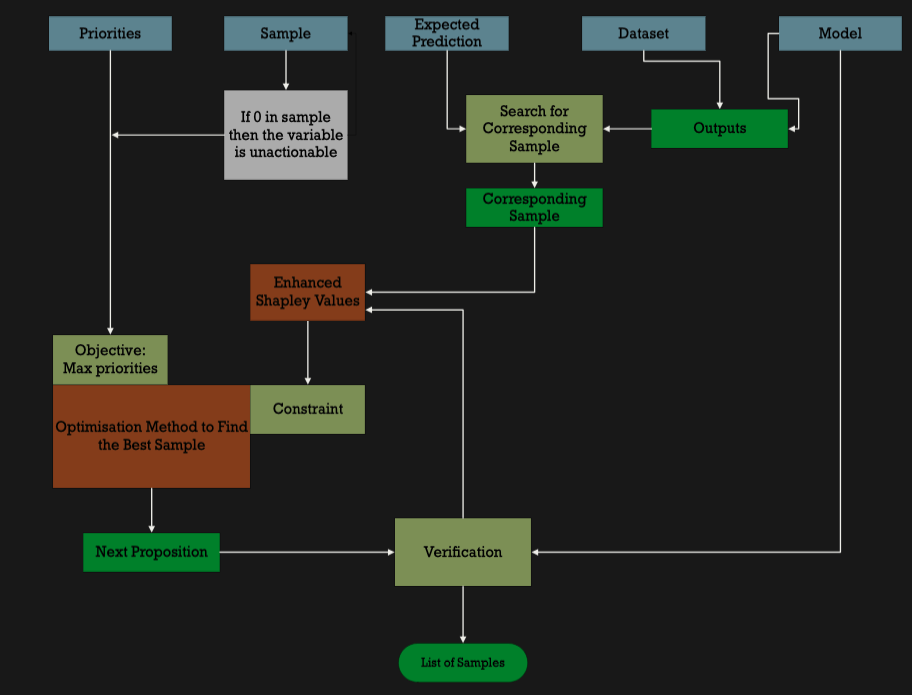

## 1. Select sample for analysis

In [3]:
sample = [                          # Features:
    0.69642857,                     # Age
    0.86359635,                     # Credit amount
    0.73529412,                     # Duration
    0., 1.,                         # Sex
    0., 0., 1., 0.,                 # Job
    0., 0., 1.,                     # Housing
    1., 0., 0., 0., 0.,             # Saving accounts
    0., 0., 1., 0.,                 # Checking account
    1., 0., 0., 0., 0., 0., 0., 0.  # Purpose
    ]

## 2. Select model and requested target
In this scenario, the requested target is probability of classification as class '1'. We want to get probability equal to $60\%$. Note, that we cannot use output of the model (model.predict), which output only $0$ or $1$. We need to use model.predict_proba available in LogisticRegression of SciKit-learn. In this case the output are two values: (probability of class '0', probability of class '1'). We are interested only in the latter, so we select $0.60$ as out requested target, meaning "probability of class '1'".

In [4]:
model_pred = lambda x: model.predict_proba(x)[:,1] # selecting output interesting for me
target = 0.60

## 3. Indicate barriers and priorities. 
By "barriers" we mean min/max values. By "priorities" we mean weight functions that indicate which values of features are preferable to us and which are not.

### Detailed instructions
The priorities need to be written in dictionary of such format:
```python
{
    'numerical':{
        index x: <priority value>,
        index y: <priority value>,
        ...
    }

    'categorical':{
        (index a1, index b1, ..., index n1) : {
            (1, 0, ..., 0) : <priority value>,
            (0, 1, ..., 0) : <priority value>,
            ...
        },
        (index a2, index b2, ..., index n2) : {
            (1, 0, ..., 0) : <priority value>,
            (0, 1, ..., 0) : <priority value>,
            ...
        }
        ...
    }
}
```

- Numerical (continuous) features:
  - unactionable : use int 0 instead of ```<priority value>```, this means that the value from the sample will be used and will not participate in selection based on priority
  - actionable: use ```{'function':<f(x)>,'min': <min value>, 'max': <max value>}```
    - replace ```<f(x)>``` with given function $f : [0, 1]$ 
    - replace ```<min value>``` and ```<max value>``` with respective values (floats or integers)
- Categorical features:
  - for given indices (index a1, index b1, ..., index n1) create dictionary mapping all possible categories to $0$ (don't use) or $1$ (can be used). The algorithm will then be able to use allowed categories and omit forbidden. You can also use other values than $1$ for permitted categories form range $(0, 1]$ to indicate priority. In this case, larger value makes the priority higher.

### Column names
The column names and indices in this example are as follows:
```python
'column': index

'Age': 0
'Credit amount': 1
'Duration': 2

'Sex_female': 3
'Sex_male': 4

'Job_0': 5
'Job_1': 6
'Job_2': 7
'Job_3':8

'Housing_free': 9
'Housing_own': 10
'Housing_rent': 11

'Saving accounts_little': 12
'Saving accounts_missing': 13
'Saving accounts_moderate': 14
'Saving accounts_quite rich': 15
'Saving accounts_rich': 16

'Checking account_little': 17
'Checking account_missing': 18
'Checking account_moderate': 19
'Checking account_rich': 20

'Purpose_business': 21
'Purpose_car': 22
'Purpose_domestic appliances': 23
'Purpose_education': 24
'Purpose_furniture/equipment': 25
'Purpose_radio/TV': 26
'Purpose_repairs': 27
'Purpose_vacation/others': 28
```

In [5]:
min_cred_am = 0.35 # 0.45 #0.65
max_cred_am = X.iloc[1,:].max()
min_duration = 0.30 # 0.40 #0.60
max_duration = X.iloc[2,:].max()

def cred_am_weight(x):
    return exponential(x, x0=0.65, x1=0.86, increasing=True, a = 5)

def duration_weight(x):
    return exponential(x, x0=0.60, x1=0.73, increasing=True, a = 5)

priorities = {
    'numerical':{0: 0, # unactionable
                1: {'function':cred_am_weight,'min':min_cred_am, 'max':max_cred_am},
                2: {'function':duration_weight,'min':min_duration, 'max':max_duration}
},
    'categorical':{
                (3,4): {(1.0, 0.0): 0,
                        (0.0, 1.0): 1},
                (5,6,7,8): {(1.0,0.0,0.0,0.0): 0,
                            (0.0,1.0,0.0,0.0): 0,
                            (0.0,0.0,1.0,0.0): 1,
                            (0.0,0.0,0.0,1.0): 1},
                (9,10,11): {(1.0, 0.0, 0.0): 1,
                            (0.0, 1.0, 0.0): 1,
                            (0.0, 0.0, 1.0): 1},
                (12,13,14,15,16): {(1.0, 0.0, 0.0, 0.0, 0.0): 1,
                                    (0.0, 1.0, 0.0, 0.0, 0.0): 1,
                                    (0.0, 0.0, 1.0, 0.0, 0.0): 1,
                                    (0.0, 0.0, 0.0, 1.0, 0.0): 0,
                                    (0.0, 0.0, 0.0, 0.0, 1.0): 0},
                (17,18,19,20): {(1.0, 0.0, 0.0, 0.0): 1,
                                (0.0, 1.0, 0.0, 0.0): 1,
                                (0.0, 0.0, 1.0, 0.0): 1,
                                (0.0, 0.0, 0.0, 1.0): 0},
                (21,22,23,24,25,26,27,28): {(1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0): 1,
                                            (0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0): 1,
                                            (0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0): 1,
                                            (0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0): 1,
                                            (0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0): 1,
                                            (0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0): 1,
                                            (0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0): 1,
                                            (0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0): 1}
    }
}


# 4. I look for the sample that results in a prediction the closest to the specified target

In [6]:
explainer = MINLSearchExplainer(model_pred, priorities, sample, target, dataset=X.values, closest_sample_epsilon=0.01)
# explainer.find_closest_elem(epsilon=0.01)

2025-11-03 12:37:40,226 - INFO - explainit - Finding the closest element in the dataset based on the specified priorities...


# 5. Calculate Shapley values between original and newly selected sample

In [7]:
# Calculating Shapley values - how each features moved the prediction from the original sample to the "closest" one

shap_vals = explainer.calc_shapley(r=explainer.sample)

# 6. Use Shapley values with priorities from point 3 and find the most optimal combination of variables 

In [267]:
def create_modified_priorities(priorities, shap_vals, sample, closest_sample):
    """
    Create modified priorities dictionary based on SHAP values and sample data.
    
    For categorical features:
    - If SHAP value is 0: keep only the category from sample
    - If SHAP value is not 0: keep categories from both sample and closest_sample
    
    Args:
        priorities: Original priorities dictionary
        shap_vals: SHAP values array/list (corresponds to feature groups, not individual indices)
        sample: Current sample values array/list
        closest_sample: Closest sample values array/list
    
    Returns:
        tuple: (modified_priorities_dict, all_combinations_dict, shap_values_dict)
    """
    import copy
    import itertools
    
    # Create a deep copy of the original priorities
    modified_priorities = copy.deepcopy(priorities)
    
    # Dictionary to store SHAP values by index
    shap_values_dict = {
        'numerical': {},
        'categorical': {}
    }
    
    # Store allowed combinations for each categorical group
    allowed_combinations_by_group = []
    all_categorical_indices = []
    
    # Process numerical features first
    for feature_id in priorities['numerical'].keys():
        if feature_id < len(shap_vals):
            shap_values_dict['numerical'][feature_id] = shap_vals[feature_id]
        else:
            shap_values_dict['numerical'][feature_id] = 0.0
    
    # Create mapping from feature groups to SHAP indices
    shap_index = len(priorities['numerical'])
    
    # Process categorical features
    for feature_indices, categorical_weights in priorities['categorical'].items():
        # Extract values for this categorical group from sample and closest_sample
        sample_values = tuple(float(sample[idx]) for idx in feature_indices)
        closest_values = tuple(float(closest_sample[idx]) for idx in feature_indices)
        
        # Get SHAP value for this categorical group
        if shap_index < len(shap_vals):
            shap_val = shap_vals[shap_index]
        else:
            shap_val = 0.0
        
        # Store SHAP value for this categorical group
        shap_values_dict['categorical'][feature_indices] = shap_val
        
        # Create new categorical weights dictionary and collect allowed combinations
        new_categorical_weights = {}
        group_combinations = []
        
        if shap_val == 0:
            # Keep only the category from sample
            if sample_values in categorical_weights:
                new_categorical_weights[sample_values] = categorical_weights[sample_values]
                group_combinations.append(sample_values)
        else:
            # Keep categories from both sample and closest_sample
            if sample_values in categorical_weights:
                new_categorical_weights[sample_values] = categorical_weights[sample_values]
                group_combinations.append(sample_values)
            if closest_values in categorical_weights and closest_values != sample_values:
                new_categorical_weights[closest_values] = categorical_weights[closest_values]
                group_combinations.append(closest_values)
        
        # Update the modified priorities
        modified_priorities['categorical'][feature_indices] = new_categorical_weights
        
        # Store for cross-product calculation
        allowed_combinations_by_group.append(group_combinations)
        all_categorical_indices.extend(feature_indices)
        
        shap_index += 1
    
    # Generate all possible combinations across all categorical groups
    all_combinations = {}
    combination_id = 0
    
    # Use itertools.product to get all combinations across groups
    for combination_tuple in itertools.product(*allowed_combinations_by_group):
        # Create dictionary mapping each categorical index to its value
        combination_dict = {}
        
        # Track position in the flattened combination
        value_index = 0
        group_index = 0
        
        for feature_indices in priorities['categorical'].keys():
            group_values = combination_tuple[group_index]
            for i, idx in enumerate(feature_indices):
                combination_dict[idx] = group_values[i]
            group_index += 1
        
        all_combinations[combination_id] = combination_dict
        combination_id += 1
    
    return modified_priorities, all_combinations, shap_values_dict

priorities_for_search, cat_combinations, shap_dict = create_modified_priorities(priorities, shap_vals, sample, explainer.closest_sample)

In [268]:
# Constraint function
# phi1(x1b) + phi2(x2b) + phi3(x3b) + phi4*(x4b-x4a) + phi5*(x5b-x5a) + phi6*(x6b-x6a) + ya -> yb


def constraint_function(x, shap_dict, sample, closest_sample, priorities_for_search, basic_prediction):
    """
    Constraint function based on SHAP values and feature changes. Returns the cumulative effect of feature changes on the prediction.
    Args:
        x: Current feature values array/list
        shap_dict: Dictionary containing SHAP values for numerical and categorical features
        sample: Original sample feature values array/list
        closest_sample: Closest sample feature values array/list
        priorities_for_search: Modified priorities dictionary
    Returns:
        float: Cumulative effect of feature changes on the prediction. 
        Basically the difference between model_pred(x) and model_pred(sample) according to Shapley values.
    """
    num_shap=shap_dict['numerical']
    cat_shap=shap_dict['categorical']

    result = basic_prediction

    for i, key in enumerate(priorities_for_search['numerical'].keys()):

        temp_unit_phi = num_shap[key]/(closest_sample[key] - sample[key])

        result += temp_unit_phi * (x[i] - sample[key])
    
    for i, key in enumerate(priorities_for_search['categorical'].keys()):
        feature_indices = key
        shap_value = cat_shap[feature_indices]
        
        # Extract current values from x
        current_values = tuple(float(x[idx]) for idx in feature_indices) #tuple(float(x[len(priorities_for_search['numerical']) + i + j]) for j in range(len(feature_indices)))
        
        sample_values = tuple(float(sample[idx]) for idx in feature_indices)
        closest_values = tuple(float(closest_sample[idx]) for idx in feature_indices)

        if current_values == sample_values:
            result += 0.0
        elif current_values == closest_values:
            result += shap_value
        else:
            raise ValueError("Invalid categorical combination encountered for indices {}: {}".format(feature_indices, current_values))

    return result
 
x = [                          # Features:
    0.69642857,                     # Age
    0.86359635,                    # Credit amount
    0.73529412,                     # Duration
    0.0, 1.0,                       # Sex
    0.0, 0.0, 1.0, 0.0,                # Job
    0.0, 0.0, 1.0,                    # Housing
    1.0, 0.0, 0.0, 0.0, 0.0,             # Saving accounts
    0.0, 0.0, 1.0, 0.0,                 # Checking account
    1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  # Purpose
    ]
x = sample.copy()
x = explainer.closest_sample.copy()
constraint_function(x, shap_dict, sample, explainer.closest_sample, priorities_for_search, basic_prediction=model_pred([sample])[0]
)

np.float64(0.5991859220257465)

In [269]:
def constraint_function(x, shap_dict, sample, closest_sample, priorities_for_search, basic_prediction):
    """
    Constraint function based on SHAP values and feature changes. Returns the cumulative effect of feature changes on the prediction.
    Args:
        x: Current feature values array/list
        shap_dict: Dictionary containing SHAP values for numerical and categorical features
        sample: Original sample feature values array/list
        closest_sample: Closest sample feature values array/list
        priorities_for_search: Modified priorities dictionary
    Returns:
        float: Cumulative effect of feature changes on the prediction. 
        Basically the difference between model_pred(x) and model_pred(sample) according to Shapley values.
    """
    num_shap=shap_dict['numerical']
    cat_shap=shap_dict['categorical']

    result = basic_prediction

    for i, key in enumerate(priorities_for_search['numerical'].keys()):

        temp_unit_phi = num_shap[key]/(closest_sample[key] - sample[key])
        
        result += temp_unit_phi * (x[i] - sample[key])
    
    for i, key in enumerate(priorities_for_search['categorical'].keys()):
        feature_indices = key
        shap_value = cat_shap[feature_indices]
        
        # Extract current values from x
        current_values = tuple(float(x[idx]) for idx in feature_indices) #tuple(float(x[len(priorities_for_search['numerical']) + i + j]) for j in range(len(feature_indices)))
        
        sample_values = tuple(float(sample[idx]) for idx in feature_indices)
        closest_values = tuple(float(closest_sample[idx]) for idx in feature_indices)

        if current_values == sample_values:
            result += 0.0
        elif current_values == closest_values:
            result += shap_value
        else:
            raise ValueError("Invalid categorical combination encountered for indices {}: {}".format(feature_indices, current_values))

    return result

x = explainer.closest_sample.copy()
constraint_function(x, shap_dict, sample, explainer.closest_sample, priorities_for_search, basic_prediction=model_pred([sample])[0]
)

np.float64(0.5991859220257465)

In [270]:
def extract_for_linear_search(target, cat_combinations, shap_dict, sample, closest_sample, priorities_for_search, basic_prediction):
    num_shap = shap_dict['numerical']
    cat_shap = shap_dict['categorical']

    new_targets = {}
    coef_times_original = 0.0
    shap_coeffs = {}
    unactionable_sum = 0.0
    for i, key in enumerate(priorities_for_search['numerical'].keys()):
        temp_unit_phi = num_shap[key]/(closest_sample[key] - sample[key])
        if type(priorities_for_search['numerical'][key]) is dict:
            min_val = priorities_for_search['numerical'][key]['min']
            max_val = priorities_for_search['numerical'][key]['max']
            shap_coeffs[key] = {'coeff':temp_unit_phi, 'min_max':(min_val, max_val)}
            coef_times_original += temp_unit_phi * sample[key]
        else: 
            min_val = None
            max_val = None
            unactionable_sum += temp_unit_phi * sample[key]
        


    
    for combo_idx, combo in cat_combinations.items():
        result = 0.0
        if not combo:
            print("Empty combination, skipping")
            continue

        # ensure array is large enough for the highest index (max index is inclusive)
        max_idx = max(combo.keys())
        dummy_x = np.zeros(max_idx + 1, dtype=float)

        for idx, val in combo.items():
            dummy_x[idx] = val


        for i, key in enumerate(priorities_for_search['categorical'].keys()):
            feature_indices = key
            shap_value = cat_shap[feature_indices]
        
            # Extract current values from x
            current_values = tuple(float(dummy_x[idx]) for idx in feature_indices) #tuple(float(x[len(priorities_for_search['numerical']) + i + j]) for j in range(len(feature_indices)))
        
            sample_values = tuple(float(sample[idx]) for idx in feature_indices)
            closest_values = tuple(float(closest_sample[idx]) for idx in feature_indices)
        
            if current_values == sample_values:
                result += 0.0
            elif current_values == closest_values:
                result += shap_value
            else:
                raise ValueError("Invalid categorical combination encountered for indices {}: {}".format(feature_indices, current_values))

        new_targets[combo_idx] = target - result - basic_prediction + coef_times_original #- unactionable_sum

    return new_targets, shap_coeffs

target_for_combo, shap_coefficients = extract_for_linear_search(target, cat_combinations, shap_dict, sample, explainer.closest_sample, priorities_for_search, basic_prediction=model_pred([sample])[0])
target_for_combo, shap_coefficients

({0: np.float64(-0.14937403750546813),
  1: np.float64(-0.1703452675702108),
  2: np.float64(-0.05168485057040623),
  3: np.float64(-0.07265608063514889),
  4: np.float64(-0.24332690508709837),
  5: np.float64(-0.26429813515184103),
  6: np.float64(-0.14563771815203647),
  7: np.float64(-0.16660894821677913)},
 {1: {'coeff': np.float64(-0.15474443081805664),
   'min_max': (0.35, np.float64(1.0))},
  2: {'coeff': np.float64(-0.3617593357073188),
   'min_max': (0.3, np.float64(1.0))}})

In [51]:
def extract_linear_constraints_for_combinations(cat_combinations, shap_dict, sample, closest_sample, priorities_for_search, basic_prediction, target):
    """
    Extract linear constraint coefficients, bounds, and targets for each categorical combination.
    """
    num_shap = shap_dict['numerical']
    cat_shap = shap_dict['categorical']
    
    # Get actionable numerical features (exclude those with value 0 in priorities)
    actionable_numerical = {}
    numerical_bounds = {}
    
    for key, priority_info in priorities_for_search['numerical'].items():
        if priority_info != 0:  # Skip non-actionable features
            actionable_numerical[key] = num_shap[key] / (closest_sample[key] - sample[key])
            # FIXED: Transform bounds to (x_i - sample_i) space
            min_bound = priority_info['min'] - sample[key]
            max_bound = priority_info['max'] - sample[key]
            numerical_bounds[key] = (min_bound, max_bound)
    
    results = {}
    
    for combination_id, cat_values in cat_combinations.items():
        # Calculate categorical contribution for this combination
        categorical_contribution = basic_prediction
        
        for feature_indices, shap_value in cat_shap.items():
            # Get values for this categorical feature group in current combination
            current_cat_values = tuple(cat_values[idx] for idx in feature_indices)
            sample_cat_values = tuple(sample[idx] for idx in feature_indices)
            closest_cat_values = tuple(closest_sample[idx] for idx in feature_indices)
            
            if current_cat_values == sample_cat_values:
                categorical_contribution += 0.0
            elif current_cat_values == closest_cat_values:
                categorical_contribution += shap_value
            else:
                raise ValueError(f"Invalid categorical combination for indices {feature_indices}")
        
        # Calculate target for numerical features
        numerical_target = target - categorical_contribution
        
        # Prepare coefficients and bounds for actionable numerical features
        coefficients = []
        bounds = []
        sample_adjustments = []
        
        for key in sorted(actionable_numerical.keys()):
            coefficients.append(actionable_numerical[key])
            bounds.append(numerical_bounds[key])  # Now correctly transformed
            sample_adjustments.append(sample[key])
        
        results[combination_id] = {
            'coefficients': coefficients,
            'bounds': bounds,
            'target': numerical_target,
            'sample_values': sample_adjustments,
            'categorical_contribution': categorical_contribution,
            'note': 'bounds are for (x_i - sample_i), solution needs to be added back to sample values'
        }
    
    return results

constraints = extract_linear_constraints_for_combinations(
    cat_combinations, shap_dict, sample, closest_sample=explainer.closest_sample, 
    priorities_for_search=priorities_for_search, basic_prediction=model_pred([sample])[0], target=target
)


In [271]:
from scipy.optimize import linprog
import numpy as np
import warnings

def solve_linear_constraint_lp(coefficients, target, bounds, method='auto', tolerance=1e-8):
    """
    Production-ready linear programming solver for constraint satisfaction
    
    Args:
        coefficients: array-like, coefficients [a₁, a₂, ..., aₙ]
        target: float, target value for a₁x₁ + a₂x₂ + ... + aₙxₙ = target
        bounds: list of tuples, [(min₁, max₁), (min₂, max₂), ...]
        method: str, LP algorithm ('highs', 'interior-point', 'revised simplex')
        tolerance: float, tolerance for constraint satisfaction
    
    Returns:
        dict: {'success': bool, 'solution': array, 'message': str, 'method_used': str}
    """
    coefficients = np.array(coefficients)
    n = len(coefficients)
    
    # Input validation
    if len(bounds) != n:
        return {'success': False, 'solution': None, 
                'message': 'Bounds length must match coefficients length', 'method_used': None}
    
    # Check if all coefficients are zero
    if np.allclose(coefficients, 0):
        if abs(target) < tolerance:
            # Any point in bounds is a solution
            solution = np.array([(b[0] + b[1])/2 for b in bounds])
            return {'success': True, 'solution': solution, 
                   'message': 'Trivial solution (all coefficients zero)', 'method_used': 'analytical'}
        else:
            return {'success': False, 'solution': None, 
                   'message': 'No solution (all coefficients zero, target non-zero)', 'method_used': None}
    
    # Try different methods if auto is selected
    methods_to_try = ['highs', 'interior-point'] if method == 'auto' else [method]
    
    for current_method in methods_to_try:
        try:
            # Set up LP problem
            # Convert equality to two inequalities
            A_ub = np.array([coefficients, -coefficients])
            b_ub = np.array([target, -target])
            
            # Dummy objective (just find feasible point)
            c = np.zeros(n)
            
            # Suppress warnings for cleaner output
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                result = linprog(
                    c=c,
                    A_ub=A_ub,
                    b_ub=b_ub,
                    bounds=bounds,
                    method=current_method,
                    options={'presolve': True}
                )
            
            if result.success:
                # Verify solution
                constraint_value = np.dot(coefficients, result.x)
                error = abs(constraint_value - target)
                
                if error < tolerance:
                    return {
                        'success': True,
                        'solution': result.x,
                        'message': f'Solution found with error {error:.2e}',
                        'method_used': current_method,
                        'constraint_value': constraint_value,
                        'error': error
                    }
        
        except Exception as e:
            continue
    
    # If no method worked, try corner analysis
    return _fallback_corner_analysis(coefficients, target, bounds, tolerance)

def _fallback_corner_analysis(coefficients, target, bounds, tolerance):
    """Fallback method using corner point analysis"""
    corners = []
    for bound in bounds:
        corners.append([bound[0], bound[1]])
    
    import itertools
    corner_points = list(itertools.product(*corners))
    
    best_error = float('inf')
    best_solution = None
    
    for corner in corner_points:
        corner = np.array(corner)
        value = np.dot(coefficients, corner)
        error = abs(value - target)
        
        if error < best_error:
            best_error = error
            best_solution = corner
    
    if best_error < tolerance:
        return {
            'success': True,
            'solution': best_solution,
            'message': f'Corner solution found with error {best_error:.2e}',
            'method_used': 'corner_analysis',
            'constraint_value': np.dot(coefficients, best_solution),
            'error': best_error
        }
    else:
        return {
            'success': False,
            'solution': None,
            'message': f'No feasible solution found. Best error: {best_error:.2e}',
            'method_used': 'corner_analysis'
        }

# Example usage
# coefficients = [2, 3, -1, 4, 0.5]
# target = 15
# bounds = [(0, 5), (-2, 3), (0, 4), (-1, 2), (0, 1)]

# result = solve_linear_constraint_lp(coefficients, target, bounds)
# print(f"Success: {result['success']}")
# print(f"Message: {result['message']}")
# if result['success']:
#     print(f"Solution: {result['solution']}")
#     print(f"Method used: {result['method_used']}")
#     print(f"Constraint error: {result['error']:.2e}")


# def extract_linear_constraints_for_combinations_v2(cat_combinations, shap_dict, sample, closest_sample, priorities_for_search, basic_prediction, target):
#     """
#     Alternative approach: formulate constraint as sum(coeff_i * x_i) = adjusted_target
#     """
#     num_shap = shap_dict['numerical']
#     cat_shap = shap_dict['categorical']
    
#     actionable_numerical = {}
#     numerical_bounds = {}
    
#     for key, priority_info in priorities_for_search['numerical'].items():
#         if priority_info != 0:
#             actionable_numerical[key] = num_shap[key] / (closest_sample[key] - sample[key])
#             numerical_bounds[key] = (priority_info['min'], priority_info['max'])  # Keep original bounds
    
#     results = {}
    
#     for combination_id, cat_values in cat_combinations.items():
#         # Calculate categorical contribution
#         categorical_contribution = basic_prediction
        
#         for feature_indices, shap_value in cat_shap.items():
#             current_cat_values = tuple(cat_values[idx] for idx in feature_indices)
#             sample_cat_values = tuple(sample[idx] for idx in feature_indices)
#             closest_cat_values = tuple(closest_sample[idx] for idx in feature_indices)
            
#             if current_cat_values == sample_cat_values:
#                 categorical_contribution += 0.0
#             elif current_cat_values == closest_cat_values:
#                 categorical_contribution += shap_value
#             else:
#                 raise ValueError(f"Invalid categorical combination for indices {feature_indices}")
        
#         # FIXED: Adjust target to account for sample baseline
#         # Original: sum(coeff_i * (x_i - sample_i)) = target - categorical_contribution
#         # Rearranged: sum(coeff_i * x_i) = target - categorical_contribution + sum(coeff_i * sample_i)
        
#         coefficients = []
#         bounds = []
#         sample_adjustments = []
#         sample_baseline = 0
        
#         for key in sorted(actionable_numerical.keys()):
#             coeff = actionable_numerical[key]
#             coefficients.append(coeff)
#             bounds.append(numerical_bounds[key])
#             sample_adjustments.append(sample[key])
#             sample_baseline += coeff * sample[key]  # Add baseline contribution
        
#         # Adjusted target includes the baseline
#         adjusted_target = target - categorical_contribution + sample_baseline
        
#         results[combination_id] = {
#             'coefficients': coefficients,
#             'bounds': bounds,
#             'target': adjusted_target,  # Now correctly adjusted
#             'sample_values': sample_adjustments,
#             'categorical_contribution': categorical_contribution,
#             'sample_baseline': sample_baseline,
#             'note': 'constraint is sum(coeff_i * x_i) = adjusted_target'
#         }
    
#     return results

In [261]:
target_for_combo, shap_coefficients = extract_for_linear_search(target, cat_combinations, shap_dict, sample, explainer.closest_sample, priorities_for_search, basic_prediction=model_pred([sample])[0])
target_for_combo, shap_coefficients

({0: np.float64(-0.14937403750546813),
  1: np.float64(-0.1703452675702108),
  2: np.float64(-0.05168485057040623),
  3: np.float64(-0.07265608063514889),
  4: np.float64(-0.24332690508709837),
  5: np.float64(-0.26429813515184103),
  6: np.float64(-0.14563771815203647),
  7: np.float64(-0.16660894821677913)},
 {1: {'coeff': np.float64(-0.15474443081805664),
   'min_max': (0.45, np.float64(1.0))},
  2: {'coeff': np.float64(-0.3617593357073188),
   'min_max': (0.4, np.float64(1.0))}})

In [272]:
# 0.20535732109365337
target_for_combo, shap_coefficients = extract_for_linear_search(target, cat_combinations, shap_dict, sample, explainer.closest_sample, priorities_for_search, basic_prediction=model_pred([sample])[0])
coeff_to_linear_search = [elem['coeff'] for elem in shap_coefficients.values()]
bounds_for_linear_search = [elem['min_max'] for elem in shap_coefficients.values()]
# min_bounds = np.array([elem[0] for elem in bounds_for_linear_search])
# max_bounds = np.array([elem[1] for elem in bounds_for_linear_search])
# min_sum=sum(min_bounds * np.array(coeff_to_linear_search))
# max_sum=sum(max_bounds * np.array(coeff_to_linear_search))

for combination_id, temp_target in target_for_combo.items():
    temp_combo = cat_combinations[combination_id]
    max_idx = max(temp_combo.keys())
    dummy_x = sample.copy()

    for idx, val in temp_combo.items():
        dummy_x[idx] = val

    linear_solution = solve_linear_constraint_lp(coeff_to_linear_search, temp_target, bounds_for_linear_search, method='auto', tolerance=10.1)
    print(linear_solution['success'])
    solution = linear_solution['solution']
    print('solution: ', solution)
    if solution is not None:
        dummy_x[1] = float(solution[0])
        dummy_x[2] = float(solution[1])
        print('sample: ', sample)
        print('dummy_x: ', dummy_x)
        print('constraint_function: ',constraint_function(dummy_x, shap_dict, sample, explainer.closest_sample, priorities_for_search, basic_prediction=model_pred([sample])[0]))
    # )
# # # Test with the corrected function
# constraints_fixed = extract_linear_constraints_for_combinations_v2(
#     cat_combinations, shap_dict, sample, closest_sample=explainer.closest_sample, 
#     priorities_for_search=priorities_for_search, basic_prediction=model_pred([sample])[0], target=target
# )

# for combination_id, combination in constraints_fixed.items():
#     print(f"\n--- Combination {combination_id} ---")
#     coefficients = combination['coefficients']
#     target_val = combination['target']
#     bounds = combination['bounds']
    
#     print(f"Coefficients: {coefficients}")
#     print(f"Target: {target_val}")
#     print(f"Bounds: {bounds}")
    
#     result = solve_linear_constraint_lp(coefficients, target_val, bounds, tolerance=1e-6)
#     print(f"Success: {result['success']}")
#     print(f"Message: {result['message']}")
    
#     if result['success']:
#         print(f"Solution: {result['solution']}")
#         print(f"Method used: {result['method_used']}")
#         print(f"Constraint error: {result['error']:.2e}")
        
#         # Verify the solution
#         constraint_check = np.dot(coefficients, result['solution'])
#         print(f"Constraint verification: {constraint_check:.6f} (target: {target_val:.6f})")

True
solution:  [0.35 0.3 ]
sample:  [0.69642857, 0.86359635, 0.73529412, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
dummy_x:  [0.69642857, 0.35, 0.3, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
constraint_function:  0.5866856860069527
True
solution:  [0.39948104 0.3       ]
sample:  [0.69642857, 0.86359635, 0.73529412, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
dummy_x:  [0.69642857, 0.39948104452752864, 0.3, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
constraint_function:  0.6
True
solution:  [0.35 0.3 ]
sample:  [0.69642857, 0.86359635, 0.73529412, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0

In [313]:
explainer.confirm_existence_of_solution_for_combo()

2025-11-03 11:25:28,150 - INFO - explainit - linear_solution["success"]: False
2025-11-03 11:25:28,151 - INFO - explainit - solution: None
2025-11-03 11:25:28,152 - INFO - explainit - linear_solution["success"]: True
2025-11-03 11:25:28,152 - INFO - explainit - solution: [0.39948104 0.3       ]
2025-11-03 11:25:28,153 - INFO - explainit - sample: [0.69642857, 0.86359635, 0.73529412, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
2025-11-03 11:25:28,153 - INFO - explainit - dummy_x: [0.69642857, np.float64(0.39948104452752864), np.float64(0.3), 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
2025-11-03 11:25:28,153 - INFO - explainit - constraint_function: 0.6
2025-11-03 11:25:28,156 - INFO - explainit - linear_solution["success"]: False
2025-11-03 11:25:28,156 - INFO - explainit - solution: None
2025-11-03 11:25:28,159 - IN

({1: {'initial_solution': {1: np.float64(0.39948104452752864),
    2: np.float64(0.3)},
   'categorical_combo': {3: 0.0,
    4: 1.0,
    5: 0.0,
    6: 0.0,
    7: 1.0,
    8: 0.0,
    9: 0.0,
    10: 0.0,
    11: 1.0,
    12: 1.0,
    13: 0.0,
    14: 0.0,
    15: 0.0,
    16: 0.0,
    17: 0.0,
    18: 0.0,
    19: 1.0,
    20: 0.0,
    21: 0.0,
    22: 1.0,
    23: 0.0,
    24: 0.0,
    25: 0.0,
    26: 0.0,
    27: 0.0,
    28: 0.0}},
  4: {'initial_solution': {1: np.float64(0.8711079530441714),
    2: np.float64(0.3)},
   'categorical_combo': {3: 0.0,
    4: 1.0,
    5: 0.0,
    6: 0.0,
    7: 1.0,
    8: 0.0,
    9: 0.0,
    10: 1.0,
    11: 0.0,
    12: 1.0,
    13: 0.0,
    14: 0.0,
    15: 0.0,
    16: 0.0,
    17: 0.0,
    18: 0.0,
    19: 1.0,
    20: 0.0,
    21: 1.0,
    22: 0.0,
    23: 0.0,
    24: 0.0,
    25: 0.0,
    26: 0.0,
    27: 0.0,
    28: 0.0}},
  5: {'initial_solution': {1: np.float64(0.35),
    2: np.float64(0.5808767421431051)},
   'categorical_combo': {3: 0

In [ ]:
# Objective function

def calculate_total_weight(priorities, values):
    """
    Calculate total weight based on priorities dictionary and input values list.
    Validates that all values are within allowed ranges or acceptable categorical combinations.
    
    Args:
        priorities: Dictionary containing numerical and categorical priorities
        values: List of values where each element corresponds to its index
    
    Returns:
        float: Total calculated weight
    
    Raises:
        ValueError: If any value is outside allowed range or invalid categorical combination
    """
    total_weight = 0
    
    # Process numerical features
    for feature_id, feature_config in priorities['numerical'].items():
        if feature_id >= len(values):
            raise ValueError(f"Not enough values provided. Missing value for index {feature_id}")
        
        current_value = values[feature_id]
        
        if feature_config == 0:  # unactionable
            # No validation needed, contributes 0 to total weight
            pass
        else:
            # Validate value is within min/max range
            min_val = feature_config['min']
            max_val = feature_config['max']
            
            if current_value < min_val or current_value > max_val:
                raise ValueError(f"Value {current_value} at index {feature_id} is outside allowed range [{min_val}, {max_val}]")
            
            # Apply the weight function
            function = feature_config['function']
            weight = function(current_value)
            total_weight += weight
    
    # Process categorical features
    for feature_indices, categorical_weights in priorities['categorical'].items():
        # Extract values for this categorical group using their indices
        group_values = []
        for idx in feature_indices:
            if idx >= len(values):
                raise ValueError(f"Not enough values provided. Missing value for index {idx}")
            group_values.append(float(values[idx]))
        
        # Convert to tuple for dictionary lookup
        value_tuple = tuple(group_values)
        
        # Validate categorical combination exists in allowed combinations
        if value_tuple not in categorical_weights:
            allowed_combinations = list(categorical_weights.keys())
            raise ValueError(f"Invalid categorical combination: {value_tuple} for features {feature_indices}. "
                           f"Allowed combinations: {allowed_combinations}")
        
        # Add weight for this categorical combination
        total_weight += categorical_weights[value_tuple]
    
    return total_weight

values = [                          # Features:
    10000.69642857,                 # Age
    0.99,                           # Credit amount
    0.73529412,                     # Duration
    0., 1.,                         # Sex
    0., 0., 1., 0.,                 # Job
    0., 0., 1.,                     # Housing
    1., 0., 0., 0., 0.,             # Saving accounts
    1., 0., 0., 0.,                 # Checking account
    1., 0., 0., 0., 0., 0., 0., 0.  # Purpose
    ]

calculate_total_weight(priorities_for_search, values)

np.float64(8.0)

In [207]:
import numpy as np
from scipy.optimize import minimize

# Original objective function (to maximize)
def original_objective(x):
    return x[0]**2 + x[1]**2 + x[2] + x[3]**3 + x[4]

# Negated objective function (for minimization)
def objective(x):
    return -original_objective(x)

# Nonlinear constraint
def constraint(x):
    return x[0] + x[1]**2 + x[2] - x[3] + x[4]**0.5

# Bounds for 5 variables
bounds = [(0, 10), (1, 5), (0, 1), (-10, 10), (0, 20)]

# Initial guess
x0 = np.array([1, 1, 1, 1, 1])

# Constraint definition
constraints = {'type': 'eq', 'fun': constraint}

# Solve
result = minimize(
    objective,  # This is -f(x)
    x0,
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

# The optimal solution is in result.x
print("Optimal solution:", result.x)
print("Maximized objective value:", -result.fun)  # Negate back to get f(x)


Optimal solution: [8.99999896e+00 1.00000000e+00 3.08491630e-12 1.00000000e+01
 4.10636892e-12]
Maximized objective value: 1081.99998133639


In [213]:
priorities


{'numerical': {0: 0,
  1: {'function': <function __main__.cred_am_weight(x)>,
   'min': 0.65,
   'max': np.float64(1.0)},
  2: {'function': <function __main__.duration_weight(x)>,
   'min': 0.6,
   'max': np.float64(1.0)}},
 'categorical': {(3, 4): {(1.0, 0.0): 0, (0.0, 1.0): 1},
  (5, 6, 7, 8): {(1.0, 0.0, 0.0, 0.0): 0,
   (0.0, 1.0, 0.0, 0.0): 0,
   (0.0, 0.0, 1.0, 0.0): 1,
   (0.0, 0.0, 0.0, 1.0): 1},
  (9, 10, 11): {(1.0, 0.0, 0.0): 1, (0.0, 1.0, 0.0): 1, (0.0, 0.0, 1.0): 1},
  (12, 13, 14, 15, 16): {(1.0, 0.0, 0.0, 0.0, 0.0): 1,
   (0.0, 1.0, 0.0, 0.0, 0.0): 1,
   (0.0, 0.0, 1.0, 0.0, 0.0): 1,
   (0.0, 0.0, 0.0, 1.0, 0.0): 0,
   (0.0, 0.0, 0.0, 0.0, 1.0): 0},
  (17, 18, 19, 20): {(1.0, 0.0, 0.0, 0.0): 1,
   (0.0, 1.0, 0.0, 0.0): 1,
   (0.0, 0.0, 1.0, 0.0): 1,
   (0.0, 0.0, 0.0, 1.0): 0},
  (21,
   22,
   23,
   24,
   25,
   26,
   27,
   28): {(1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0): 1, (0.0,
    1.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0): 1, (0.0, 0.0, 1.0, 0.0,

In [301]:
create_bunds(priorities, sample)

[(0.69642857, 0.69642857), (0.35, np.float64(1.0)), (0.3, np.float64(1.0))]

In [314]:
import numpy as np
from scipy.optimize import minimize


def create_bunds(priorities, sample):
    bounds = []
    num_part = priorities['numerical']
    for idx, value in num_part.items():
        if type(value) is dict:
            temp_bound = (value['min'], value['max'])
        elif value == 0:
            temp_bound = (sample[idx], sample[idx])
        bounds.append(temp_bound)

    return bounds

bounds = create_bunds(priorities, sample)
x0 = np.array([explainer.closest_sample[idx] for idx in priorities['numerical'].keys()])
epsilon = 0.01

for i, values in cat_combinations.items():
    prepared_input = np.zeros_like(sample)

    for idx, val in values.items():
        prepared_input[idx] = val

    def constraint_wrapper(x, shap_dict, sample, closest_sample, priorities_for_search, basic_prediction, ready_input):
        for idx in shap_dict['numerical'].keys():
            ready_input[idx] = x[idx]

        return constraint_function(ready_input, shap_dict, sample, closest_sample, priorities_for_search, basic_prediction)

    # constraint_fun = lambda x: constraint_wrapper(x, shap_dict, sample, explainer.closest_sample, priorities_for_search, basic_prediction=model_pred([sample])[0], ready_input=prepared_input)
    # print(constraint_fun(x))
    def objective_wrapper(x, priorities_for_search, ready_input):
        for idx in shap_dict['numerical'].keys():
            ready_input[idx] = x[idx]
        return calculate_total_weight(priorities_for_search, ready_input)

    # objective_fun = lambda x: -objective_wrapper(x, priorities_for_search, prepared_input)
    print('prepared_input:', prepared_input)

    constraint_fun = lambda x: constraint_wrapper(x, shap_dict, sample, explainer.closest_sample, priorities_for_search, basic_prediction=model_pred([sample])[0], ready_input=prepared_input.copy())

    objective_fun = lambda x: -objective_wrapper(x, priorities_for_search, prepared_input.copy())

    # def h(x):
    #     return x[0] + x[1]**2 + x[2] - x[3] + x[4]**0.5

    # Lower bound constraint: h(x) >= target - epsilon
    def lower_constraint(x):
        return constraint_fun(x) - (target - epsilon)

    # Upper bound constraint: h(x) <= target + epsilon
    def upper_constraint(x):
        return (target + epsilon) - constraint_fun(x)

    # Constraint definition
    constraints = [
        {'type': 'ineq', 'fun': lower_constraint},  # h(x) >= target - epsilon
        {'type': 'ineq', 'fun': upper_constraint}   # h(x) <= target + epsilon
    ]

    # Solve
    result = minimize(
        objective_fun, 
        x0,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints,
    )
    
    # The optimal solution is in result.x
    complete_solution = prepared_input.copy()
    for j, idx in enumerate(shap_dict['numerical'].keys()):
        complete_solution[idx] = result.x[j]
    
    # Print results
    print("Combination values: ", values)
    print("Optimal numerical solution:", result.x)
    print("Complete solution (prepared_input with optimal numerical values):", model_pred([complete_solution]))
    print("Constraint value at solution:", constraint_fun(result.x))
    print("Maximized objective value:", -result.fun)
    print("-----")

    # constraint_fun = lambda x: constraint_function(x, shap_dict, sample, explainer.closest_sample, priorities_for_search, basic_prediction=model_pred([sample]))

prepared_input: [0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0.
 0. 0. 0. 0. 0.]


NameError: name 'calculate_total_weight' is not defined

In [8]:
counterfactuals = explainer.find_counterfactuals()

2025-11-03 12:38:39,511 - INFO - explainit - linear_solution["success"]: False
2025-11-03 12:38:39,511 - INFO - explainit - solution: None
2025-11-03 12:38:39,513 - INFO - explainit - linear_solution["success"]: True
2025-11-03 12:38:39,513 - INFO - explainit - solution: [0.39948104 0.3       ]
2025-11-03 12:38:39,513 - INFO - explainit - sample: [0.69642857, 0.86359635, 0.73529412, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
2025-11-03 12:38:39,513 - INFO - explainit - dummy_x: [0.69642857, np.float64(0.39948104452752864), np.float64(0.3), 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
2025-11-03 12:38:39,514 - INFO - explainit - constraint_function: 0.6
2025-11-03 12:38:39,517 - INFO - explainit - linear_solution["success"]: False
2025-11-03 12:38:39,517 - INFO - explainit - solution: None
2025-11-03 12:38:39,519 - IN

In [9]:
counterfactuals

[[np.float64(0.69642857),
  np.float64(0.39948104452752864),
  np.float64(0.3),
  0.0,
  1.0,
  0.0,
  0.0,
  1.0,
  0.0,
  0.0,
  0.0,
  1.0,
  1.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  1.0,
  0.0,
  0.0,
  1.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0],
 [np.float64(0.69642857),
  np.float64(0.8711079530441714),
  np.float64(0.3),
  0.0,
  1.0,
  0.0,
  0.0,
  1.0,
  0.0,
  0.0,
  1.0,
  0.0,
  1.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  1.0,
  0.0,
  1.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0],
 [np.float64(0.69642857),
  np.float64(0.35),
  np.float64(0.5808767421431051),
  0.0,
  1.0,
  0.0,
  0.0,
  1.0,
  0.0,
  0.0,
  1.0,
  0.0,
  1.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  1.0,
  0.0,
  0.0,
  1.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0],
 [np.float64(0.69642857),
  np.float64(0.3753359471325555),
  np.float64(0.3),
  0.0,
  1.0,
  0.0,
  0.0,
  1.0,
  0.0,
  0.0,
  1.0,
  0.0,
  1.0,
  0.0,
  0.0,
  0.0,
  0.0,
  1.0,
  0.0,
  0.0,
  0.0,
  0.0,


In [248]:
import numpy as np
from scipy.optimize import minimize

def find_feasible_starting_point(bounds, constraint_fun, target, epsilon, max_attempts=100):
    """
    Find a feasible starting point that satisfies the constraints.
    
    Args:
        bounds: List of (min, max) tuples for each variable
        constraint_fun: Constraint function
        target: Target constraint value
        epsilon: Constraint tolerance
        max_attempts: Maximum random attempts
    
    Returns:
        feasible_point: Array of feasible starting values, or None if not found
    """
    
    for attempt in range(max_attempts):
        # Generate random point within bounds
        x_candidate = np.array([
            np.random.uniform(bound[0], bound[1]) for bound in bounds
        ])
        
        try:
            constraint_value = constraint_fun(x_candidate)
            
            # Check if point satisfies constraints
            if (target - epsilon) <= constraint_value <= (target + epsilon):
                print(f"Found feasible starting point after {attempt + 1} attempts")
                print(f"Constraint value: {constraint_value:.6f} (target: {target:.6f})")
                return x_candidate
                
        except Exception as e:
            # Skip invalid points
            continue
    
    print(f"Could not find feasible starting point after {max_attempts} attempts")
    return None

def find_multiple_feasible_points(bounds, constraint_fun, target, epsilon, n_points=5):
    """Find multiple feasible starting points for better optimization."""
    feasible_points = []
    
    for i in range(n_points * 10):  # Try more attempts to get n_points
        point = find_feasible_starting_point(bounds, constraint_fun, target, epsilon, max_attempts=20)
        if point is not None:
            feasible_points.append(point)
            if len(feasible_points) >= n_points:
                break
    
    return feasible_points

find_feasible_starting_point(bounds, constraint_fun, target, epsilon, max_attempts=10000)

Could not find feasible starting point after 10000 attempts


In [238]:
prepared_input

array([0.69642857, 0.65      , 0.60000001, 0.        , 1.        ,
       0.        , 0.        , 1.        , 0.        , 0.        ,
       1.        , 0.        , 1.        , 0.        , 0.        ,
       0.        , 0.        , 1.        , 0.        , 0.        ,
       0.        , 0.        , 1.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        ])

In [236]:
prepared_input

array([0.69642857, 0.65      , 0.60000001, 0.        , 1.        ,
       0.        , 0.        , 1.        , 0.        , 0.        ,
       1.        , 0.        , 1.        , 0.        , 0.        ,
       0.        , 0.        , 1.        , 0.        , 0.        ,
       0.        , 0.        , 1.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        ])

In [233]:
print([ elem for idx, elem in enumerate(prepared_input) if idx in shap_dict['numerical'].keys()])

[np.float64(0.69642857), np.float64(0.65), np.float64(0.6000000149011612)]


In [ ]:
priorities_for_search, cat_combinations, shap_dict 
constraint_function(x, shap_dict, sample, explainer.closest_sample, priorities_for_search, basic_prediction=model_pred([sample])
)
calculate_total_weight(priorities_for_search, values)

In [ ]:
from pymoo.algorithms.soo.nonconvex.ga import GA
from pymoo.optimize import minimize
from pymoo.core.problem import Problem
import numpy as np



In [ ]:
x1b = 0
x2b = 1
x3b = 1
x4b = 7
x5b = 10
x6b = 2

x1a = 1
x2a = 0
x3a = 1
x4a = 5
x5a = 3
x6a = 18

phi1 = lambda x: 6 -6*x
phi2 = lambda x: -1*x
phi3 = lambda x: 0
phi4 = -0.5
phi5 = 0.429
phi6 = -0.1875

ya = 10
yb = 20

#Constraint
# phi1(x1b) + phi2(x2b) + phi3(x3b) + phi4*(x4b-x4a) + phi5*(x5b-x5a) + phi6*(x6b-x6a) + ya -> yb



[(0, 0, 0),
 (0, 0, 1),
 (0, 1, 0),
 (0, 1, 1),
 (1, 0, 0),
 (1, 0, 1),
 (1, 1, 0),
 (1, 1, 1)]

In [ ]:
import numpy as np
from scipy.optimize import minimize

# Objective function
def objective(x):
    return x[0]**2 + x[1]**2 + x[2] + x[3]**3 + x[4]

# Nonlinear constraint
def constraint(x):
    return x[0] + x[1]**2 + x[2] - x[3] + x[4]**0.5

# Bounds for 5 variables
bounds = [(0, 10), (1, 5), (0, 1), (-10, 10), (0, 20)]

# Constraint definition
constraints = {'type': 'eq', 'fun': constraint}

# Initial guess
x0 = np.array([1, 1, 1, 1, 1])

# Solve
result = minimize(
    objective,
    x0,
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

print("Optimal solution:", result.x)
print("Objective value:", result.fun)


Optimal solution: [0.00000000e+00 1.00000000e+00 0.00000000e+00 1.00000007e+00
 3.10597052e-19]
Objective value: 2.000000207164226


In [ ]:
s1, s2, s3 = shapley_values[:3]
s4, s8, s9 = shapley_values[3], shapley_values[7], shapley_values[8]

def s5(x):
    x = np.asarray(x)
    return np.where(x == 0, 0, -0.0076962330173750764)

def s6(x):
    x = np.asarray(x)
    return np.where(x == 0, 0, 0.09844896938743553)
    
def s7(x):
    x = np.asarray(x)
    return np.where(x == 0, 0, 0.13570900988796217)

w1, w4, w5, w6, w7, w8, w9 = 0, 1,1,1,1,1,1

def exp_increasing(x, x0=0.65, x1=0.86, increasing=True, a = 5):
    """
    Exponential function from 0 to 1 (increasing) or 1 to 0 (decreasing).
    If increasing=True: 0 for x <= x0, 1 for x >= x1.
    If increasing=False: 1 for x <= x0, 0 for x >= x1.
    a : controls the steepness of the transition (the greater value of a increases steepness)
    Always returns a numpy array.
    """
    x = np.asarray(x)
    if x1 > x0:
        t = (x - x0) / (x1 - x0)
        t = np.clip(t, 0, 1)
        curve = (np.exp(a * t) - 1) / (np.exp(a) - 1)
        if increasing:
            val = np.where(x <= x0, 0.0, np.where(x >= x1, 1.0, curve))
        else:
            val = np.where(x <= x0, 1.0, np.where(x >= x1, 0.0, 1 - curve))
    else:
        val = np.zeros_like(x) if increasing else np.ones_like(x)
    return val

def w2(x):
    return exp_increasing(x, x0=0.65, x1=0.86, increasing=True, a = 5)

def w3(x):
    return exp_increasing(x, x0=0.60, x1=0.73, increasing=True, a = 5)

target = 0.40

initial_values = [0.69642857, 0.86359635, 0.73529412, 0, 0, 0, 0, 0, 0]

def target_fun(x1, x2, x3, x4, x5, x6, x7, x8, x9):

    return s1*x1 + s2*x2 + s3*x3 + s4*x4 + s5(x5) + s6(x6) + s7(x7) + s8*x8 + s9*x9

def weight_fun(x1, x2, x3, x4, x5, x6, x7, x8, x9):

    return w1 + w2(x2) + w3(x3) + w4 + w5 + w6 + w7 + w8 + w9


from pymoo.core.problem import Problem
from pymoo.algorithms.soo.nonconvex.ga import GA
from pymoo.optimize import minimize
import numpy as np

# --- Your functions and parameters ---
# s1, s2, s3, s4, s8, s9 = ... (set from shapley_values)
# s5, s6, s7, w2, w3, etc. as defined in your prompt

from pymoo.core.variable import Real, Integer

class CustomProblem(Problem):
    def __init__(self, s1, s2, s3, s4, s5_func, s6_func, s7_func, s8, s9, target):
        super().__init__(
            n_var=9,
            n_obj=1,
            n_constr=1,
            xl=[0, 0, 0, 0, 0, 0, 0, 0, 0],
            xu=[2, 2, 2, 1, 1, 1, 1, 1, 1],
            type_var=[float, float, float, int, int, int, int, int, int],  # <--- this line
        )
        self.s1, self.s2, self.s3 = s1, s2, s3
        self.s4, self.s8, self.s9 = s4, s8, s9
        self.s5_func, self.s6_func, self.s7_func = s5_func, s6_func, s7_func
        self.target = target

    def _evaluate(self, X, out, *args, **kwargs):
        x1 = X[:, 0]
        x2 = X[:, 1]
        x3 = X[:, 2]
        x4 = X[:, 3]
        x5 = X[:, 4]
        x6 = X[:, 5]
        x7 = X[:, 6]
        x8 = X[:, 7]
        x9 = X[:, 8]
        w_val = 0 + w2(x2) + w3(x3) + 1 + 1 + 1 + 1 + 1 + 1
        out["F"] = -w_val
        t_val = (
            self.s1*x1 + self.s2*x2 + self.s3*x3 + self.s4*x4 +
            self.s5_func(x5) + self.s6_func(x6) + self.s7_func(x7) +
            self.s8*x8 + self.s9*x9
        )
        out["G"] = np.abs(t_val - self.target) - 1e-1

# Example usage:
problem = CustomProblem(
    s1=shapley_values[0], s2=shapley_values[1], s3=shapley_values[2],
    s4=shapley_values[3], s5_func=s5, s6_func=s6, s7_func=s7,
    s8=shapley_values[7], s9=shapley_values[8], target=target
)
algorithm = GA(pop_size=100)

from pymoo.core.repair import Repair

class BinaryRepair(Repair):
    def _do(self, problem, X, **kwargs):
        X = X.copy()
        # Round x4-x9 to 0 or 1
        X[:, 3:9] = np.round(X[:, 3:9])
        X[:, 3:9] = np.clip(X[:, 3:9], 0, 1)
        return X

# Then pass it to minimize:
res = minimize(problem, algorithm, ('n_gen', 100), repair=BinaryRepair(), verbose=True)

# res = minimize(problem, algorithm, ('n_gen', 100), verbose=True)

if res.X is not None and res.F is not None:
    best_X = res.X.copy()
    # Ensure x4-x9 are binary in the final output
    best_X[3:9] = np.round(best_X[3:9]).astype(int)
    best_X[3:9] = np.clip(best_X[3:9], 0, 1)
    print("Best X (binary x4-x9):", best_X)
    print("Best weight_fun:", -res.F[0])
else:
    print("No feasible solution found.")


n_gen  |  n_eval  |     cv_min    |     cv_avg    |     f_avg     |     f_min    
     1 |      100 |  0.000000E+00 |  0.0717531777 | -7.941160E+00 | -8.000000E+00
     2 |      200 |  0.000000E+00 |  0.0261494075 | -7.975772E+00 | -8.000000E+00
     3 |      300 |  0.000000E+00 |  0.0045698880 | -7.982473E+00 | -8.000000E+00
     4 |      400 |  0.000000E+00 |  0.000000E+00 | -8.000000E+00 | -8.000000E+00
     5 |      500 |  0.000000E+00 |  0.000000E+00 | -8.000000E+00 | -8.000000E+00
     6 |      600 |  0.000000E+00 |  0.000000E+00 | -8.000000E+00 | -8.000000E+00
     7 |      700 |  0.000000E+00 |  0.000000E+00 | -8.000000E+00 | -8.000000E+00
     8 |      800 |  0.000000E+00 |  0.000000E+00 | -8.000000E+00 | -8.000000E+00
     9 |      900 |  0.000000E+00 |  0.000000E+00 | -8.000000E+00 | -8.000000E+00
    10 |     1000 |  0.000000E+00 |  0.000000E+00 | -8.000000E+00 | -8.000000E+00
    11 |     1100 |  0.000000E+00 |  0.000000E+00 | -8.000000E+00 | -8.000000E+00
    12 |     120